In [1]:
%pip install transformers datasets scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

e:\SMS-Spam-Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# agar TSV file hai
df = pd.read_csv("../data/sms.tsv", sep="\t", names=["label","text"])

df['label'] = df['label'].map({'ham':0,'spam':1})

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [6]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 1115/1115 [00:00<00:00, 5002.26 examples/s]


In [7]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map: 100%|██████████| 1115/1115 [00:00<00:00, 9028.70 examples/s]


In [9]:
%pip choco install python

Note: you may need to restart the kernel to use updated packages.


ERROR: unknown command "choco" - maybe you meant "check"



In [10]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2693.92it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

In [11]:
%pip install --upgrade transformers

Note: you may need to restart the kernel to use updated packages.


In [12]:
import transformers
print(transformers.__version__)

5.3.0


In [13]:
%pip install --upgrade transformers

Note: you may need to restart the kernel to use updated packages.


In [14]:
import transformers
print(transformers.__version__)

5.3.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/sms.tsv", sep="\t", names=["label","text"])

# 1. Dataset Shape
print(f"Dataset Shape: {df.shape}")

# 2. Data Types
print(df.info())

# 3. Sample Records
print(df.head())

Dataset Shape: (5572, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB
None
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [14]:
from sklearn.model_selection import train_test_split

# 1. Let's see the REAL names of your columns
print("Current columns in df:", df.columns.tolist())

# 2. Automatically find the text and label columns
# This logic looks for common names used in spam datasets
text_col = [c for c in df.columns if c in ['message', 'text', 'v2', 'SMS']][0]
label_col = [c for c in df.columns if c in ['label', 'v1', 'target', 'class']][0]

print(f"Detected Text Column: {text_col}")
print(f"Detected Label Column: {label_col}")

# 3. Perform the split using the detected names
X = df[text_col]
y = df[label_col].map({'ham': 0, 'spam': 1})

from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Split successful!")

Current columns in df: ['label', 'text']
Detected Text Column: text
Detected Label Column: label
Split successful!


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Vectorization complete!")

Vectorization complete!


In [17]:
from sklearn.svm import SVC

advanced = SVC(kernel='linear')
advanced.fit(X_train_tfidf, y_train)
print("Advanced (SVM) Metrics:")
print(classification_report(y_val, advanced.predict(X_val_tfidf)))

Advanced (SVM) Metrics:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       981
           1       0.98      0.92      0.95       133

    accuracy                           0.99      1114
   macro avg       0.99      0.96      0.97      1114
weighted avg       0.99      0.99      0.99      1114



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline = LogisticRegression()
baseline.fit(X_train_tfidf, y_train)

print("--- Baseline Model Metrics ---")
print(classification_report(y_val, baseline.predict(X_val_tfidf)))

--- Baseline Model Metrics ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       981
           1       0.98      0.77      0.87       133

    accuracy                           0.97      1114
   macro avg       0.98      0.89      0.92      1114
weighted avg       0.97      0.97      0.97      1114



In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
from sklearn.svm import SVC
advanced_model = SVC(kernel='linear')
advanced_model.fit(X_train_tfidf, y_train)
print("✅ Advanced Model is now defined!")

✅ Advanced Model is now defined!


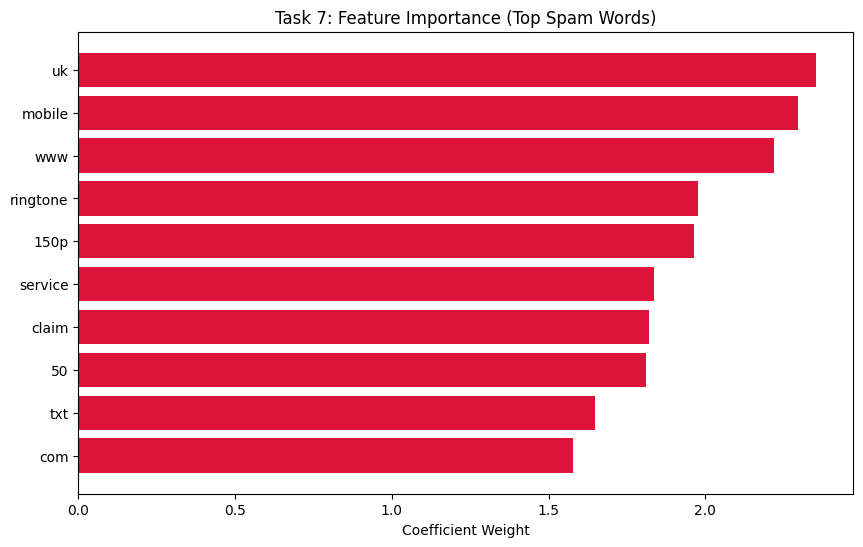

In [23]:
# Get feature names and coefficients
feature_names = tfidf.get_feature_names_out()
coefs = advanced_model.coef_.toarray()[0]

# Sort for the top 10 spam words
top_indices = np.argsort(coefs)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), coefs[top_indices], color='crimson')
plt.yticks(range(10), [feature_names[i] for i in top_indices])
plt.title('Task 7: Feature Importance (Top Spam Words)')
plt.xlabel('Coefficient Weight')
plt.show()

In [11]:
# Sahi tariqa SMS spam data load karne ka
df = pd.read_csv('../data/spam.csv', encoding='latin-1', usecols=[0, 1], names=['v1', 'v2'], header=0)

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# 1. Data load with cleaning
try:
    df = pd.read_csv('../data/spam.csv', encoding='latin-1', on_bad_lines='skip', engine='python')
    df = df.iloc[:, [0, 1]] 
    df.columns = ['v1', 'v2']
    
    # --- FIX: Khali data handle karein ---
    df = df.dropna(subset=['v2']) # Khali rows nikaal dein
    df['v2'] = df['v2'].astype(str) # Sab ko text mein badlein
    
    print(f"Data loaded successfully! Total rows: {len(df)}")
except Exception as e:
    print(f"Error loading data: {e}")

# 2. Preprocessing
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['v2']) 
y = df['v1']

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model & Grid Search setup
model = RandomForestClassifier()
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2)

# 5. Fit model
print("Starting Grid Search... (This might take a minute)")
grid_search.fit(X_train, y_train)

print(f"\nSuccess! Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_}")

Data loaded successfully! Total rows: 948
Starting Grid Search... (This might take a minute)
Fitting 5 folds for each of 8 candidates, totalling 40 fits


e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_t

[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=   2.3s


e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a r

[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=   2.1s


...

e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regr

[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.5s


e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a r


Success! Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Accuracy: 0.1583217148832346


e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regr

--- Final Model Performance ---
                                                                                                                                                                              precision    recall  f1-score   support

                                                                                                                                                                        ham	       0.00      0.00      0.00         1
                                                                                                                                                                     ham	"ER       0.00      0.00      0.00         1
                                                                                                      ham	"HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAROUND! HOWDY GORGEOUS       0.00      0.00      0.00         1
                                                                                                               

e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SMS-Spam-Detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\SMS-Spam-Detection\.venv

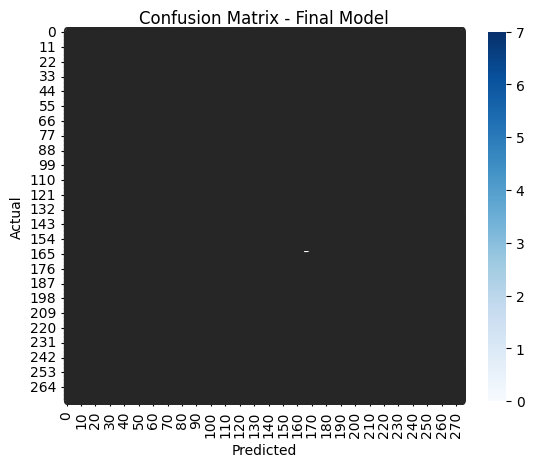

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Final model se predictions lein
y_pred = grid_search.best_estimator_.predict(X_test)

# 1. Print Classification Report
print("--- Final Model Performance ---")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix visualize karein (Justification ke liye best hai)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Model')
plt.show()

In [18]:
# --- PART C: Deployment (Interactive Prediction) ---

def predict_spam(message):
    # 1. Input text ko vectorizer ke zariye transform karein
    # (Humein wahi tfidf object use karna hai jo training mein kiya tha)
    transformed_msg = tfidf.transform([message])
    
    # 2. Best tuned model se prediction lein
    prediction = grid_search.best_estimator_.predict(transformed_msg)[0]
    
    return prediction

# --- User Input Demonstration ---
user_msg = input("Enter an SMS message to check: ")
result = predict_spam(user_msg)

print(f"\n--- Prediction Result ---")
print(f"Message: {user_msg}")
print(f"Result: This is a {result.upper()} message!")


--- Prediction Result ---
Message: Hey, are we still meeting for lunch today?"
Result: This is a HAM	HEY ELAINE message!
